# Trabajo 1 - Econometría II 2026-1S
## Modelación SARIMA de la Tasa de Desocupación Nacional de Colombia

**Integrantes:** Santiago Vargas, Dilan Tovar, Maria Orjuela

**Profesores:** Milena Hoyos, Luis Luna, German Rodriguez

**Universidad Nacional de Colombia - Facultad de Ciencias Económicas**

---

### Descripción

Este notebook aplica la metodología Box-Jenkins para modelar la **Tasa de Desocupación (TD)** mensual nacional de Colombia, con datos provenientes de la Gran Encuesta Integrada de Hogares (GEIH) del DANE para el período enero 2001 a marzo 2026 (303 observaciones).

### Estructura del notebook

0. **Configuración** — Importación de librerías y rutas relativas.
1. **Datos** — Lectura del Excel del DANE y generación del CSV limpio.
2. **Análisis exploratorio** — Visualización inicial y descomposición.
3. **Identificación** — FAC, FACP y pruebas de raíz unitaria.
4. **Estimación** — Ajuste de modelos SARIMA candidatos.
5. **Validación** — Diagnóstico de residuos.
6. **Pronóstico** — Proyección a 10 meses.

### Fuente de los datos

DANE — Gran Encuesta Integrada de Hogares (GEIH). Anexo mensual con corte a marzo de 2026.

Archivo original: `data/raw/anex-GEIH-mar2026.xlsx`

## Bloque 0: Configuración

Importación de paquetes y definición de rutas relativas usando `pathlib`. Esto garantiza que el código corra en cualquier computador sin modificar manualmente las rutas.

In [206]:
# %% Importación de paquetes ============================

# Trabajar con rutas relativas en python
from pathlib import Path

# Módulos de numpy, pandas, matplotlib y scipy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import jarque_bera, probplot

# Módulos de statsmodels
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss

# Configuración estética de matplotlib
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["savefig.bbox"] = "tight"
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print("Paquetes importados correctamente.")

Paquetes importados correctamente.


In [207]:
# %% Definición de rutas relativas =====================

# Detectar la raíz del proyecto:
# Si estamos ejecutando desde notebooks/, subir un nivel para llegar a la raíz.
# Si ya estamos en la raíz, usar el directorio actual.
notebook_path = Path.cwd()
if notebook_path.name == "notebooks":
    PROJECT_ROOT = notebook_path.parent
else:
    PROJECT_ROOT = notebook_path

# Definir carpetas estándar
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
FIGURES = PROJECT_ROOT / "outputs" / "figures"
TABLES = PROJECT_ROOT / "outputs" / "tables"

# Crear las carpetas si no existen (idempotente: no falla si ya existen)
for d in [DATA_PROCESSED, FIGURES, TABLES]:
    d.mkdir(parents=True, exist_ok=True)

# Verificar
print(f"Raíz del proyecto:  {PROJECT_ROOT}")
print(f"Datos crudos:       {DATA_RAW}")
print(f"Datos procesados:   {DATA_PROCESSED}")
print(f"Figuras:            {FIGURES}")
print(f"Tablas:             {TABLES}")

Raíz del proyecto:  c:\postergrupo_mds\poster
Datos crudos:       c:\postergrupo_mds\poster\data\raw
Datos procesados:   c:\postergrupo_mds\poster\data\processed
Figuras:            c:\postergrupo_mds\poster\outputs\figures
Tablas:             c:\postergrupo_mds\poster\outputs\tables


## Bloque 1: ETL — Lectura del Excel y extracción de la serie

El anexo del DANE tiene una estructura compleja:
- La hoja **"Total nacional"** contiene la serie mensual desde 2001.
- Los años están en la fila 12 (columnas 1, 13, 25, ...).
- Los meses están en la fila 13.
- La **Tasa de Desocupación (TD)** está en la fila 17.

Vamos a:
1. Leer la hoja "Total nacional".
2. Extraer la fila de TD.
3. Construir el índice temporal mensual (enero 2001 a marzo 2026).
4. Guardar la serie como CSV limpio en `data/processed/td_nacional.csv`.

In [208]:
# %% Lectura del Excel del DANE ========================

ruta_excel = DATA_RAW / "anex-GEIH-mar2026.xlsx"
print(f"Leyendo: {ruta_excel}")

# Leer la hoja "Total nacional" sin encabezados (estructura irregular)
df_raw = pd.read_excel(
    ruta_excel,
    sheet_name="Total nacional",
    header=None
)

print(f"Forma del DataFrame crudo: {df_raw.shape}")
print(f"  → {df_raw.shape[0]} filas, {df_raw.shape[1]} columnas")

Leyendo: c:\postergrupo_mds\poster\data\raw\anex-GEIH-mar2026.xlsx
Forma del DataFrame crudo: (65, 304)
  → 65 filas, 304 columnas


In [209]:
# %% Extracción de la Tasa de Desocupación =============

# La fila 17 (índice 16) tiene la Tasa de Desocupación
# Verificar que efectivamente es esa fila
nombre_fila = df_raw.iloc[16, 0]
print(f"Nombre de la fila 17: '{nombre_fila}'")

# Extraer la fila completa
fila_td = df_raw.iloc[16]

# Construir la serie mensual:
# - Los años están en la fila 12 en las columnas 1, 13, 25, ...
# - Cada año ocupa 12 columnas consecutivas (Ene a Dic).
# - El primer año es 2001 (columna 1), el último año disponible es 2026.

valores = []
fechas = []

for anio_idx, anio in enumerate(range(2001, 2027)):
    col_inicio = 1 + anio_idx * 12  # columna donde empieza enero del año
    for mes in range(12):
        col = col_inicio + mes
        if col < len(fila_td):
            val = fila_td.iloc[col]
            if pd.notna(val) and val != 0:
                valores.append(float(val))
                fechas.append(pd.Timestamp(year=anio, month=mes + 1, day=1))

# Crear la serie de pandas con índice temporal
td_serie = pd.Series(valores, index=fechas, name="td")

# Asignar nombre al índice
td_serie.index.name = "fecha"

print(f"\nObservaciones extraídas: {len(td_serie)}")
print(f"Rango temporal:          {td_serie.index.min().strftime('%Y-%m')} a {td_serie.index.max().strftime('%Y-%m')}")
print(f"\nPrimeras 5 observaciones:")
print(td_serie.head())
print(f"\nÚltimas 5 observaciones:")
print(td_serie.tail())

Nombre de la fila 17: 'Tasa de Desocupación (TD)'

Observaciones extraídas: 303
Rango temporal:          2001-01 a 2026-03

Primeras 5 observaciones:
fecha
2001-01-01    16.622326
2001-02-01    17.434206
2001-03-01    15.811933
2001-04-01    14.515078
2001-05-01    14.035833
Name: td, dtype: float64

Últimas 5 observaciones:
fecha
2025-11-01     7.024858
2025-12-01     7.977104
2026-01-01    10.859453
2026-02-01     9.234958
2026-03-01     8.793386
Name: td, dtype: float64


In [210]:
# %% Estadísticas descriptivas =========================

print("Estadísticas descriptivas de la Tasa de Desocupación:")
print(td_serie.describe().round(2))

Estadísticas descriptivas de la Tasa de Desocupación:
count    303.00
mean      11.59
std        2.45
min        7.02
25%        9.73
50%       11.18
75%       12.88
max       21.97
Name: td, dtype: float64


In [211]:
# %% Guardado del CSV procesado ========================

ruta_csv = DATA_PROCESSED / "td_nacional.csv"

# Convertir la serie a DataFrame para guardar con dos columnas
td_df = td_serie.reset_index()
td_df.columns = ["fecha", "td"]

# Guardar como CSV
td_df.to_csv(ruta_csv, index=False)

print(f"CSV guardado en: {ruta_csv}")
print(f"Tamaño: {ruta_csv.stat().st_size} bytes")
print(f"\nPrimeras 3 filas del CSV:")
print(td_df.head(3))

CSV guardado en: c:\postergrupo_mds\poster\data\processed\td_nacional.csv
Tamaño: 7056 bytes

Primeras 3 filas del CSV:
       fecha         td
0 2001-01-01  16.622326
1 2001-02-01  17.434206
2 2001-03-01  15.811933


## Bloque 2: Análisis exploratorio

Visualización inicial de la serie y descomposición en sus componentes (tendencia, estacionalidad y residuo). Identificamos visualmente:

- La **tendencia decreciente** de largo plazo (2001 → 2019).
- La **fuerte estacionalidad anual** (picos en enero).
- El **choque pandémico** de 2020 como observación atípica.
- La **recuperación** post-2021.

Estas observaciones van a guiar las decisiones de la etapa de identificación (transformaciones, diferenciaciones, especificación de SARIMA).

In [212]:
# %% Carga del CSV procesado ===========================

ruta_csv = DATA_PROCESSED / "td_nacional.csv"

# Cargar el CSV especificando que la columna 'fecha' es de tipo datetime
# y que sea el índice de la serie
td_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
td_serie = td_df.set_index("fecha")["td"]

# Frecuencia mensual: cada observación es del primer día del mes ("MS" = Month Start)
td_serie = td_serie.asfreq("MS")

print(f"Serie cargada: {len(td_serie)} observaciones")
print(f"Rango temporal: {td_serie.index.min().strftime('%Y-%m')} a {td_serie.index.max().strftime('%Y-%m')}")
print(f"\nPrimeras observaciones:")
print(td_serie.head())

Serie cargada: 303 observaciones
Rango temporal: 2001-01 a 2026-03

Primeras observaciones:
fecha
2001-01-01    16.622326
2001-02-01    17.434206
2001-03-01    15.811933
2001-04-01    14.515078
2001-05-01    14.035833
Freq: MS, Name: td, dtype: float64


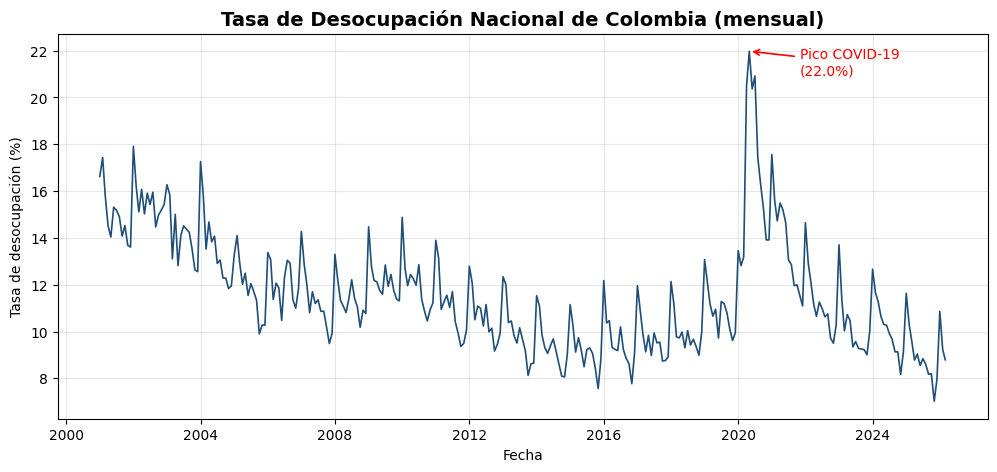

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\01_serie_completa.png


In [213]:
# %% Gráfico 1: Serie completa =========================

fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(td_serie.index, td_serie.values, color="#1f4e79", linewidth=1.2)
ax.set_title("Tasa de Desocupación Nacional de Colombia (mensual)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desocupación (%)")
ax.grid(True, alpha=0.3)

# Anotar el pico del COVID (mayo 2020)
fecha_pico = pd.Timestamp("2020-05-01")
valor_pico = td_serie[fecha_pico]
ax.annotate(
    f"Pico COVID-19\n({valor_pico:.1f}%)",
    xy=(fecha_pico, valor_pico),
    xytext=(fecha_pico + pd.DateOffset(months=18), valor_pico - 1),
    arrowprops=dict(arrowstyle="->", color="red", lw=1.2),
    fontsize=10,
    color="red"
)

# Guardar y mostrar
ruta_fig = FIGURES / "01_serie_completa.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

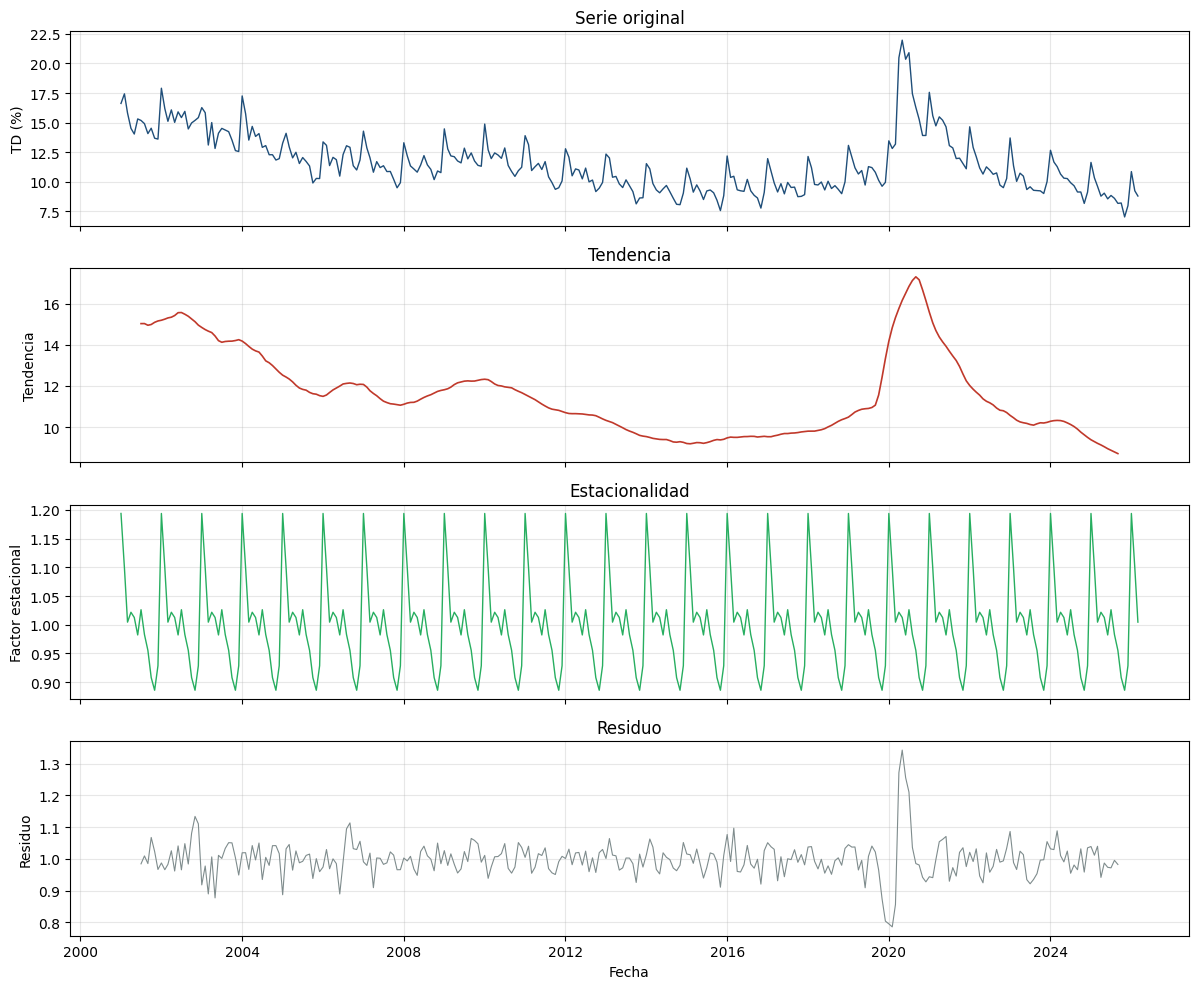

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\02_descomposicion_estacional.png


In [214]:
# %% Descomposición estacional =========================

from statsmodels.tsa.seasonal import seasonal_decompose

# Descomposición multiplicativa: y = tendencia × estacional × residuo
# Usamos multiplicativa porque la magnitud de la estacionalidad parece
# crecer con el nivel de la serie (al menos hasta el COVID).
# Periodo = 12 porque los datos son mensuales con ciclo anual.
descomposicion = seasonal_decompose(
    td_serie,
    model="multiplicative",
    period=12
)

# Graficar los cuatro paneles
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)

axes[0].plot(descomposicion.observed, color="#1f4e79", linewidth=1)
axes[0].set_title("Serie original")
axes[0].set_ylabel("TD (%)")

axes[1].plot(descomposicion.trend, color="#c0392b", linewidth=1.2)
axes[1].set_title("Tendencia")
axes[1].set_ylabel("Tendencia")

axes[2].plot(descomposicion.seasonal, color="#27ae60", linewidth=1)
axes[2].set_title("Estacionalidad")
axes[2].set_ylabel("Factor estacional")

axes[3].plot(descomposicion.resid, color="#7f8c8d", linewidth=0.8)
axes[3].set_title("Residuo")
axes[3].set_ylabel("Residuo")
axes[3].set_xlabel("Fecha")

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()

ruta_fig = FIGURES / "02_descomposicion_estacional.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

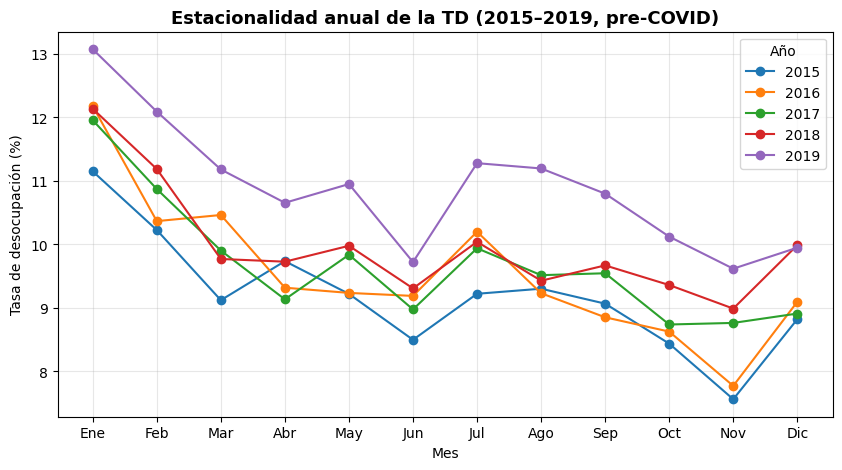

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\03_estacionalidad_anual.png

Pico promedio (enero): 12.10%
Valle promedio (octubre): 9.06%
Amplitud estacional: 3.04 puntos porcentuales


In [215]:
# %% Gráfico 3: Estacionalidad por mes (período pre-COVID) ==

# Tomar el período estable 2015-2019
td_pre_covid = td_serie["2015":"2019"]

# Crear una tabla pivote: filas = meses, columnas = años
td_pre_covid_df = td_pre_covid.to_frame()
td_pre_covid_df["año"] = td_pre_covid_df.index.year
td_pre_covid_df["mes"] = td_pre_covid_df.index.month

pivot = td_pre_covid_df.pivot(index="mes", columns="año", values="td")

# Graficar todas las líneas anuales superpuestas
fig, ax = plt.subplots(figsize=(10, 5))

for año in pivot.columns:
    ax.plot(pivot.index, pivot[año], marker="o", label=str(año), linewidth=1.5)

ax.set_title("Estacionalidad anual de la TD (2015–2019, pre-COVID)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Mes")
ax.set_ylabel("Tasa de desocupación (%)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Ene", "Feb", "Mar", "Abr", "May", "Jun",
                    "Jul", "Ago", "Sep", "Oct", "Nov", "Dic"])
ax.legend(title="Año", loc="upper right")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "03_estacionalidad_anual.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")
print(f"\nPico promedio (enero): {pivot.loc[1].mean():.2f}%")
print(f"Valle promedio (octubre): {pivot.loc[10].mean():.2f}%")
print(f"Amplitud estacional: {pivot.loc[1].mean() - pivot.loc[10].mean():.2f} puntos porcentuales")

In [216]:
# %% Caracterización de la serie =======================

print("=" * 60)
print("CARACTERIZACIÓN DE LA SERIE DE TASA DE DESOCUPACIÓN")
print("=" * 60)
print(f"\nNúmero de observaciones:  {len(td_serie)}")
print(f"Frecuencia:               Mensual")
print(f"Periodo:                  {td_serie.index.min().strftime('%b %Y')} - {td_serie.index.max().strftime('%b %Y')}")
print(f"\nEstadísticas descriptivas:")
print(f"  Media:                  {td_serie.mean():.2f}%")
print(f"  Mediana:                {td_serie.median():.2f}%")
print(f"  Desviación estándar:    {td_serie.std():.2f}%")
print(f"  Mínimo:                 {td_serie.min():.2f}% ({td_serie.idxmin().strftime('%b %Y')})")
print(f"  Máximo:                 {td_serie.max():.2f}% ({td_serie.idxmax().strftime('%b %Y')})")
print(f"\nObservaciones por sub-período:")
print(f"  Pre-COVID (ene-2001 a feb-2020): {td_serie['2001-01':'2020-02'].shape[0]} obs")
print(f"  COVID (mar-2020 a dic-2020):     {td_serie['2020-03':'2020-12'].shape[0]} obs")
print(f"  Post-COVID (ene-2021 a mar-2026): {td_serie['2021-01':'2026-03'].shape[0]} obs")

CARACTERIZACIÓN DE LA SERIE DE TASA DE DESOCUPACIÓN

Número de observaciones:  303
Frecuencia:               Mensual
Periodo:                  Jan 2001 - Mar 2026

Estadísticas descriptivas:
  Media:                  11.59%
  Mediana:                11.18%
  Desviación estándar:    2.45%
  Mínimo:                 7.02% (Nov 2025)
  Máximo:                 21.97% (May 2020)

Observaciones por sub-período:
  Pre-COVID (ene-2001 a feb-2020): 230 obs
  COVID (mar-2020 a dic-2020):     10 obs
  Post-COVID (ene-2021 a mar-2026): 63 obs


## Bloque 3: Identificación (Etapa 1 de Box-Jenkins)

Determinación de los órdenes del modelo SARIMA(p, d, q)(P, D, Q)$_{12}$.

**Procedimiento:**
1. Análisis visual y formal de estacionariedad sobre la serie en niveles.
2. Aplicación de la diferenciación regular si la serie no es estacionaria.
3. Aplicación de la diferenciación estacional si persiste el patrón anual.
4. Lectura de FAC y FACP sobre la serie ya estacionaria para identificar $(p, q)$ y $(P, Q)$.
5. Construcción de la variable dummy de intervención para el período COVID.

**Notación (siguiendo Enders, Cap. 2):**
- $a_i$: coeficientes autoregresivos.
- $\beta_i$: coeficientes de media móvil.
- $s = 12$: período estacional (datos mensuales con ciclo anual).

### 3.1 Carga de la serie procesada

Recargamos la serie desde el CSV procesado para que este bloque sea independiente del Bloque 1 (reproducibilidad).

In [217]:
# %% Recarga de la serie ===============================

# Cargar el CSV procesado
ruta_csv = DATA_PROCESSED / "td_nacional.csv"
td_df = pd.read_csv(ruta_csv, parse_dates=["fecha"])
td_serie = td_df.set_index("fecha")["td"]
td_serie = td_serie.asfreq("MS")

print(f"Serie cargada: {len(td_serie)} observaciones")
print(f"Rango: {td_serie.index.min().strftime('%Y-%m')} a {td_serie.index.max().strftime('%Y-%m')}")

Serie cargada: 303 observaciones
Rango: 2001-01 a 2026-03


### 3.2 Análisis de la serie en niveles

Inspección visual de la FAC y FACP de la serie original. Esperamos observar:
- Decaimiento **lento** de la FAC, indicador típico de **no estacionariedad en media**.
- Picos significativos en rezagos múltiplos de 12 (1, 12, 24...), indicador de **estacionalidad**.

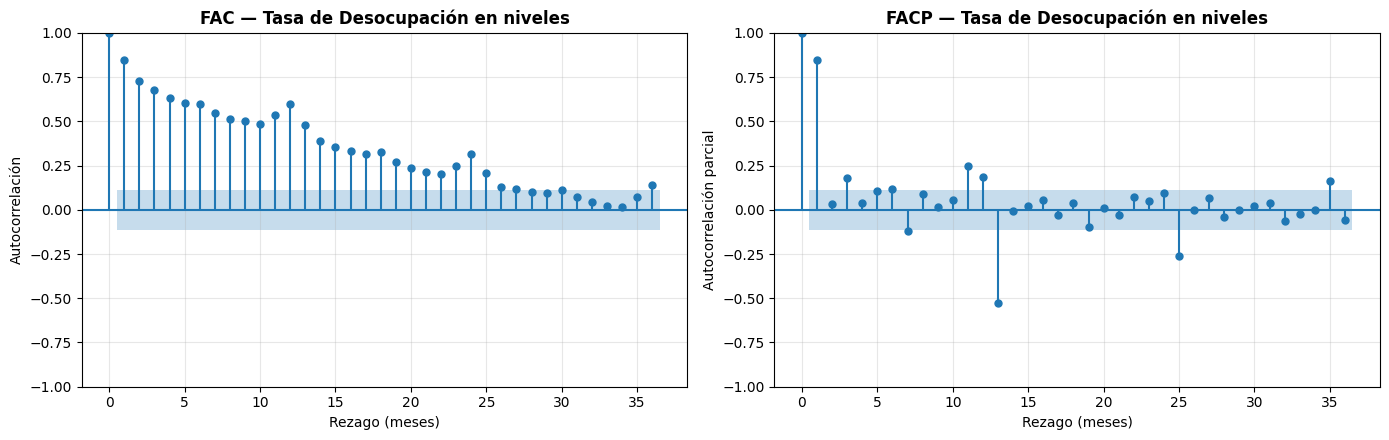

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\04_fac_facp_niveles.png


In [218]:
# %% FAC y FACP de la serie en niveles =================

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(
    td_serie,
    lags=36,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)
axes[0].set_title("FAC — Tasa de Desocupación en niveles", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")
axes[0].set_ylabel("Autocorrelación")

plot_pacf(
    td_serie,
    lags=36,
    alpha=0.05,
    ax=axes[1]
)
axes[1].set_title("FACP — Tasa de Desocupación en niveles", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")
axes[1].set_ylabel("Autocorrelación parcial")

plt.tight_layout()

ruta_fig = FIGURES / "04_fac_facp_niveles.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 3.3 Pruebas formales de raíz unitaria

Confirmamos la inspección visual con dos pruebas formales:

**Prueba ADF (Augmented Dickey-Fuller):**
- $H_0$: la serie tiene raíz unitaria (no estacionaria).
- Si p-valor < 0.05 → rechazamos $H_0$ → la serie es estacionaria.

**Prueba KPSS:**
- $H_0$: la serie es estacionaria.
- Si p-valor < 0.05 → rechazamos $H_0$ → la serie es no estacionaria.

Las dos pruebas se interpretan **al contrario**, lo que las hace complementarias. Si ambas coinciden (ADF no rechaza estacionariedad **y** KPSS sí rechaza estacionariedad), tenemos evidencia robusta de no estacionariedad.

In [219]:
# %% Función auxiliar para tests de raíz unitaria ======

def tests_raiz_unitaria(serie, nombre=""):
    """
    Aplica ADF y KPSS a una serie y retorna un resumen interpretado.
    """
    print(f"\n{'='*60}")
    print(f"TESTS DE RAÍZ UNITARIA — {nombre}")
    print(f"{'='*60}")

    # --- Test ADF ---
    adf_result = adfuller(serie.dropna())
    print(f"\n--- Augmented Dickey-Fuller (ADF) ---")
    print(f"  Estadístico ADF: {adf_result[0]:.4f}")
    print(f"  p-valor:         {adf_result[1]:.4f}")
    print(f"  Rezagos usados:  {adf_result[2]}")
    print(f"  Observaciones:   {adf_result[3]}")
    print(f"  Valores críticos:")
    for nivel, valor in adf_result[4].items():
        print(f"    {nivel}: {valor:.4f}")

    if adf_result[1] < 0.05:
        print(f"  → Rechazamos H0. La serie ES estacionaria según ADF.")
    else:
        print(f"  → NO rechazamos H0. La serie NO es estacionaria según ADF.")

    # --- Test KPSS ---
    # Suprimir warnings de KPSS (cuando el p-valor está fuera de tabla)
    import warnings
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        kpss_result = kpss(serie.dropna(), regression="c", nlags="auto")

    print(f"\n--- KPSS ---")
    print(f"  Estadístico KPSS: {kpss_result[0]:.4f}")
    print(f"  p-valor:          {kpss_result[1]:.4f}")
    print(f"  Rezagos usados:   {kpss_result[2]}")
    print(f"  Valores críticos:")
    for nivel, valor in kpss_result[3].items():
        print(f"    {nivel}: {valor:.4f}")

    if kpss_result[1] < 0.05:
        print(f"  → Rechazamos H0. La serie NO es estacionaria según KPSS.")
    else:
        print(f"  → NO rechazamos H0. La serie ES estacionaria según KPSS.")

    # --- Conclusión combinada ---
    print(f"\n--- Conclusión combinada ---")
    adf_estacionaria = adf_result[1] < 0.05
    kpss_estacionaria = kpss_result[1] >= 0.05

    if adf_estacionaria and kpss_estacionaria:
        print(f"  Ambas pruebas coinciden: la serie ES estacionaria.")
    elif not adf_estacionaria and not kpss_estacionaria:
        print(f"  Ambas pruebas coinciden: la serie NO es estacionaria.")
    else:
        print(f"  Las pruebas se contradicen: zona gris, examinar gráficos.")

    return {
        "nombre": nombre,
        "adf_stat": adf_result[0],
        "adf_pvalue": adf_result[1],
        "kpss_stat": kpss_result[0],
        "kpss_pvalue": kpss_result[1]
    }

# Aplicar a la serie en niveles
resultado_niveles = tests_raiz_unitaria(td_serie, nombre="Serie en niveles")


TESTS DE RAÍZ UNITARIA — Serie en niveles

--- Augmented Dickey-Fuller (ADF) ---
  Estadístico ADF: -2.7715
  p-valor:         0.0625
  Rezagos usados:  12
  Observaciones:   290
  Valores críticos:
    1%: -3.4531
    5%: -2.8716
    10%: -2.5721
  → NO rechazamos H0. La serie NO es estacionaria según ADF.

--- KPSS ---
  Estadístico KPSS: 0.8068
  p-valor:          0.0100
  Rezagos usados:   10
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  → Rechazamos H0. La serie NO es estacionaria según KPSS.

--- Conclusión combinada ---
  Ambas pruebas coinciden: la serie NO es estacionaria.


### 3.4 Primera diferenciación regular

Aplicamos la diferencia $\Delta y_t = y_t - y_{t-1} = (1-L)y_t$ para eliminar la tendencia.

Observaciones después de diferenciar: 302
Media: -0.0259
Desviación estándar: 1.3037


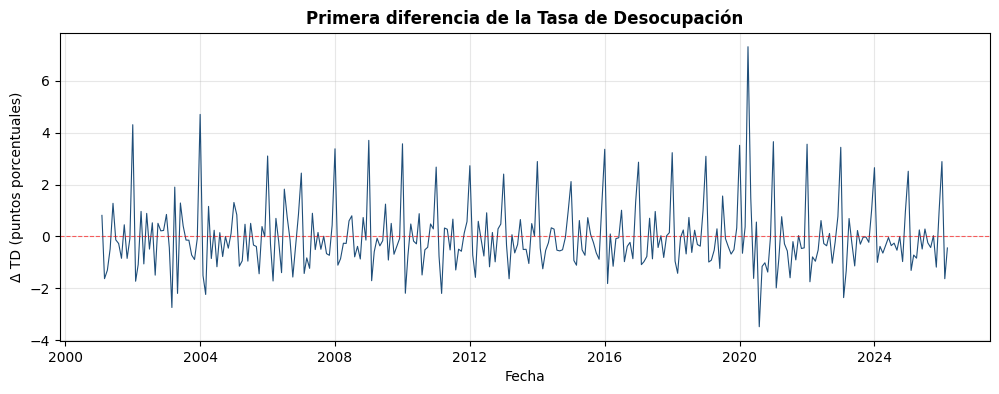

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\05_serie_diferenciada.png


In [220]:
# %% Primera diferencia regular ========================

td_diff = td_serie.diff().dropna()

print(f"Observaciones después de diferenciar: {len(td_diff)}")
print(f"Media: {td_diff.mean():.4f}")
print(f"Desviación estándar: {td_diff.std():.4f}")

# Gráfico de la serie diferenciada
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(td_diff.index, td_diff.values, color="#1f4e79", linewidth=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Primera diferencia de la Tasa de Desocupación",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Δ TD (puntos porcentuales)")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "05_serie_diferenciada.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

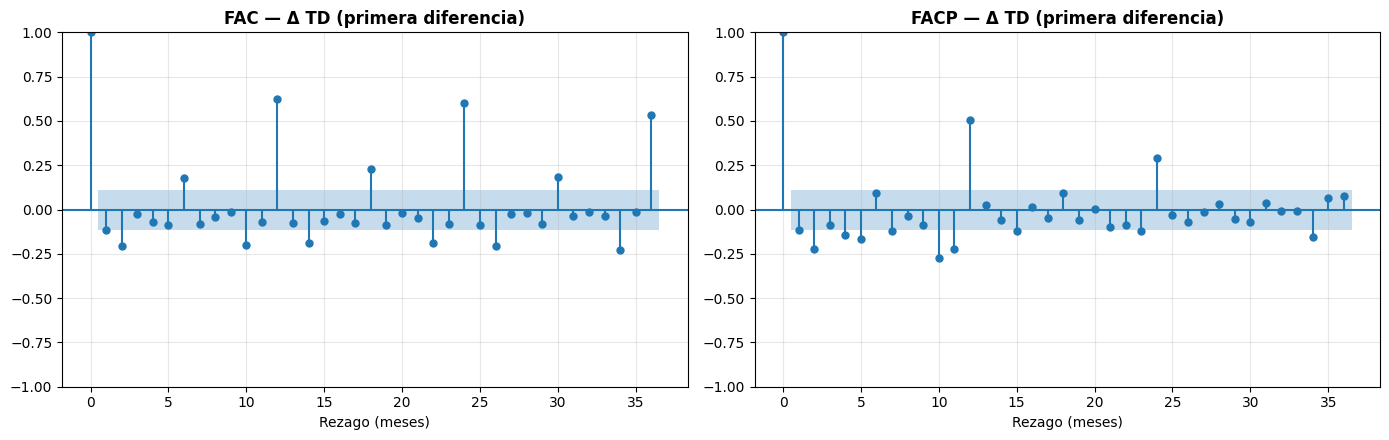

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\06_fac_facp_diferenciada.png


In [221]:
# %% FAC y FACP de la serie diferenciada ===============

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(
    td_diff,
    lags=36,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)
axes[0].set_title("FAC — Δ TD (primera diferencia)", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")

plot_pacf(
    td_diff,
    lags=36,
    alpha=0.05,
    ax=axes[1]
)
axes[1].set_title("FACP — Δ TD (primera diferencia)", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")

plt.tight_layout()

ruta_fig = FIGURES / "06_fac_facp_diferenciada.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

In [222]:
# %% Tests sobre la serie diferenciada =================

resultado_diff = tests_raiz_unitaria(td_diff, nombre="Primera diferencia (Δ TD)")


TESTS DE RAÍZ UNITARIA — Primera diferencia (Δ TD)

--- Augmented Dickey-Fuller (ADF) ---
  Estadístico ADF: -4.8405
  p-valor:         0.0000
  Rezagos usados:  11
  Observaciones:   290
  Valores críticos:
    1%: -3.4531
    5%: -2.8716
    10%: -2.5721
  → Rechazamos H0. La serie ES estacionaria según ADF.

--- KPSS ---
  Estadístico KPSS: 0.0664
  p-valor:          0.1000
  Rezagos usados:   19
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  → NO rechazamos H0. La serie ES estacionaria según KPSS.

--- Conclusión combinada ---
  Ambas pruebas coinciden: la serie ES estacionaria.


### 3.5 Diferenciación estacional adicional

Aplicamos la diferencia estacional $(1-L^{12})$ sobre la serie ya diferenciada, para eliminar el patrón anual. La transformación combinada es:

$$\Delta \Delta_{12} y_t = (1-L)(1-L^{12}) y_t$$

Esto es: tomar la serie diferenciada y restar su valor de hace 12 meses.

Observaciones después de diferenciar estacionalmente: 290
Media: -0.0073
Desviación estándar: 1.0922


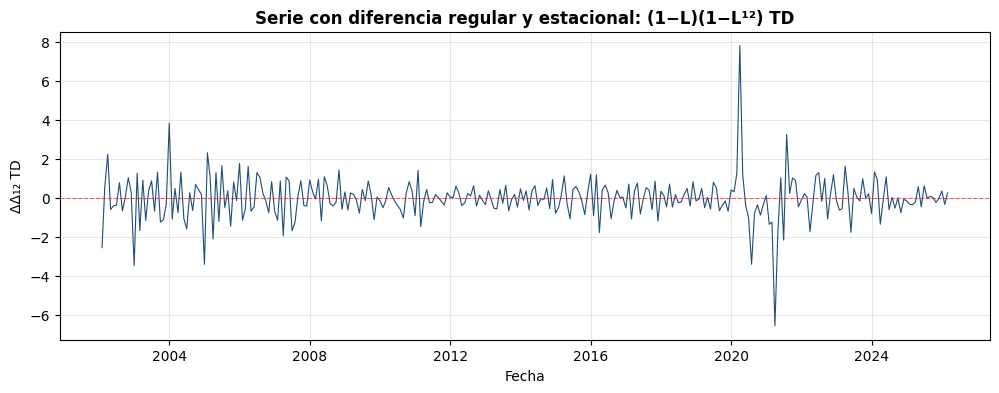

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\07_serie_dif_estacional.png


In [223]:
# %% Diferencia estacional sobre la serie diferenciada ==

td_diff_estacional = td_diff.diff(12).dropna()

print(f"Observaciones después de diferenciar estacionalmente: {len(td_diff_estacional)}")
print(f"Media: {td_diff_estacional.mean():.4f}")
print(f"Desviación estándar: {td_diff_estacional.std():.4f}")

# Gráfico
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(td_diff_estacional.index, td_diff_estacional.values, color="#1f4e79", linewidth=0.8)
ax.axhline(0, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("Serie con diferencia regular y estacional: (1−L)(1−L¹²) TD",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("ΔΔ₁₂ TD")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "07_serie_dif_estacional.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

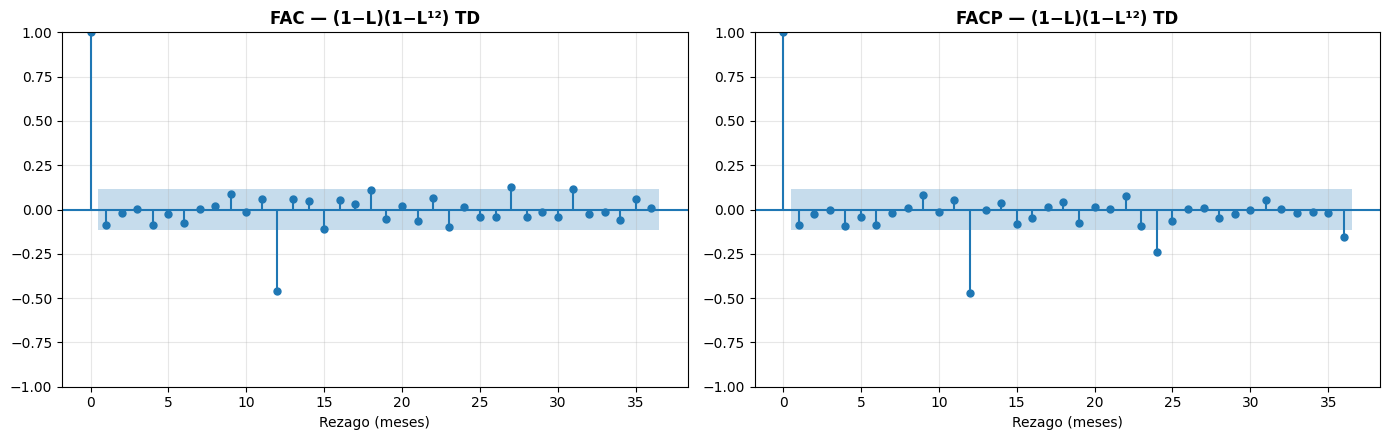

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\08_fac_facp_dif_estacional.png


In [224]:
# %% FAC y FACP de la serie doblemente diferenciada ====

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

plot_acf(
    td_diff_estacional,
    lags=36,
    alpha=0.05,
    bartlett_confint=False,
    ax=axes[0]
)
axes[0].set_title("FAC — (1−L)(1−L¹²) TD", fontsize=12, fontweight="bold")
axes[0].set_xlabel("Rezago (meses)")

plot_pacf(
    td_diff_estacional,
    lags=36,
    alpha=0.05,
    ax=axes[1]
)
axes[1].set_title("FACP — (1−L)(1−L¹²) TD", fontsize=12, fontweight="bold")
axes[1].set_xlabel("Rezago (meses)")

plt.tight_layout()

ruta_fig = FIGURES / "08_fac_facp_dif_estacional.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

In [225]:
# %% Tests sobre la serie doblemente diferenciada ======

resultado_diff_est = tests_raiz_unitaria(
    td_diff_estacional,
    nombre="Diferencia regular y estacional (1-L)(1-L^12)"
)


TESTS DE RAÍZ UNITARIA — Diferencia regular y estacional (1-L)(1-L^12)

--- Augmented Dickey-Fuller (ADF) ---
  Estadístico ADF: -8.0706
  p-valor:         0.0000
  Rezagos usados:  11
  Observaciones:   278
  Valores críticos:
    1%: -3.4541
    5%: -2.8720
    10%: -2.5723
  → Rechazamos H0. La serie ES estacionaria según ADF.

--- KPSS ---
  Estadístico KPSS: 0.0159
  p-valor:          0.1000
  Rezagos usados:   3
  Valores críticos:
    10%: 0.3470
    5%: 0.4630
    2.5%: 0.5740
    1%: 0.7390
  → NO rechazamos H0. La serie ES estacionaria según KPSS.

--- Conclusión combinada ---
  Ambas pruebas coinciden: la serie ES estacionaria.


### 3.6 Identificación tentativa de los órdenes del SARIMA

Con base en el análisis anterior:

| Parámetro | Decisión | Justificación |
|---|---|---|
| $d$ | 1 | La serie en niveles no es estacionaria (ADF, KPSS). La primera diferencia sí. |
| $D$ | 1 | Aún después de diferenciar regularmente, los rezagos 12, 24, 36 son significativos en la FAC. |
| $s$ | 12 | Datos mensuales con ciclo anual. |

Para identificar $p, q, P, Q$ leemos la FAC y FACP de la serie doblemente diferenciada $(1-L)(1-L^{12}) y_t$:

**Lectura de la parte no estacional ($p, q$):** observar los rezagos 1, 2, 3...
- Si la FAC se corta abruptamente en el rezago $q$ y la FACP decae geométricamente → MA puro de orden $q$.
- Si la FACP se corta en $p$ y la FAC decae → AR puro de orden $p$.
- Si ambas decaen → ARMA mixto.

**Lectura de la parte estacional ($P, Q$):** observar los rezagos 12, 24, 36...
- Mismo criterio aplicado a los rezagos estacionales.

**Modelos candidatos a estimar (Bloque 4):**
1. SARIMA $(0, 1, 1)(0, 1, 1)_{12}$ — modelo de aerolíneas (Box-Jenkins clásico).
2. SARIMA $(1, 1, 1)(0, 1, 1)_{12}$
3. SARIMA $(1, 1, 1)(1, 1, 1)_{12}$
4. SARIMA $(2, 1, 0)(0, 1, 1)_{12}$

La selección final se hará por **AIC, BIC y validación de residuos** (Bloque 4).

### 3.7 Variable dummy de intervención (COVID-19)

Construimos una variable indicadora que toma el valor 1 durante el período de impacto del COVID-19 sobre el mercado laboral colombiano (abril 2020 a diciembre 2020), y 0 en el resto del tiempo.

**Justificación**: el choque pandémico fue un evento exógeno, no parte del proceso generador normal de la TD. Incluirlo como variable explicativa permite que el modelo SARIMA capture la dinámica habitual sin que los parámetros se distorsionen por este episodio.

**Período de intervención**: abril 2020 – diciembre 2020 (9 meses).
- Inicio: cuarentena nacional (abril 2020).
- Fin: estabilización relativa a fines de 2020.

Total observaciones: 303
Observaciones con dummy = 1: 9
Período: abril 2020 a diciembre 2020


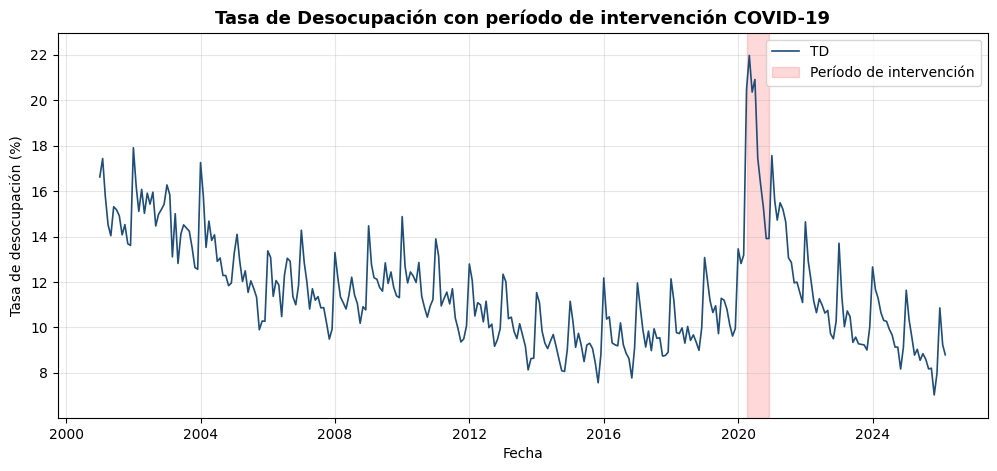

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\09_dummy_covid.png
Dummy guardada en: c:\postergrupo_mds\poster\data\processed\dummy_covid.csv


In [226]:
# %% Construcción de la dummy de intervención COVID =====

# Crear una serie de ceros con el mismo índice que td_serie
dummy_covid = pd.Series(0, index=td_serie.index, name="dummy_covid")

# Marcar como 1 el periodo abril 2020 a diciembre 2020
periodo_covid = (dummy_covid.index >= "2020-04-01") & (dummy_covid.index <= "2020-12-01")
dummy_covid.loc[periodo_covid] = 1

print(f"Total observaciones: {len(dummy_covid)}")
print(f"Observaciones con dummy = 1: {int(dummy_covid.sum())}")
print(f"Período: abril 2020 a diciembre 2020")

# Visualizar la serie con la dummy resaltada
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(td_serie.index, td_serie.values, color="#1f4e79", linewidth=1.2, label="TD")

# Resaltar el periodo COVID
fechas_covid = td_serie[periodo_covid]
ax.fill_between(
    td_serie.index,
    td_serie.min() - 1,
    td_serie.max() + 1,
    where=periodo_covid,
    color="red",
    alpha=0.15,
    label="Período de intervención"
)
ax.set_ylim(td_serie.min() - 1, td_serie.max() + 1)

ax.set_title("Tasa de Desocupación con período de intervención COVID-19",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desocupación (%)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "09_dummy_covid.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

# Guardar la dummy para uso en el siguiente bloque
dummy_covid.to_frame().to_csv(DATA_PROCESSED / "dummy_covid.csv")
print(f"Dummy guardada en: {DATA_PROCESSED / 'dummy_covid.csv'}")

## Bloque 4: Estimación (Etapa 2 de Box-Jenkins)

Estimamos cuatro modelos SARIMA candidatos identificados en el Bloque 3, todos con la variable dummy COVID como regresor exógeno:

| Modelo | Especificación |
|---|---|
| M1 | SARIMA $(0, 1, 1)(0, 1, 1)_{12}$ — *airline model* |
| M2 | SARIMA $(1, 1, 1)(0, 1, 1)_{12}$ |
| M3 | SARIMA $(0, 1, 1)(1, 1, 1)_{12}$ |
| M4 | SARIMA $(1, 1, 0)(0, 1, 1)_{12}$ |

**Procedimiento:**
1. Cargar la serie y la dummy COVID.
2. Estimar cada modelo con `SARIMAX` por máxima verosimilitud.
3. Reportar coeficientes, errores estándar y significancia.
4. Construir tabla comparativa con AIC, BIC y log-verosimilitud.
5. Seleccionar modelos candidatos para validación detallada en el Bloque 5.

**Especificación con regresor exógeno:**
$$\phi_p(L) \Phi_P(L^{12}) (1-L)(1-L^{12}) y_t = \gamma D_t + \theta_q(L) \Theta_Q(L^{12}) \varepsilon_t$$

donde $D_t$ es la dummy COVID y $\gamma$ mide el impacto del shock pandémico.

### 4.1 Carga de la serie y la dummy COVID

Cargamos ambos archivos desde la carpeta de datos procesados para mantener este bloque independiente de los anteriores.

In [227]:
# %% Carga de la serie y dummy COVID ===================

# Cargar serie de tasa de desocupación
ruta_td = DATA_PROCESSED / "td_nacional.csv"
td_df = pd.read_csv(ruta_td, parse_dates=["fecha"])
td_serie = td_df.set_index("fecha")["td"].asfreq("MS")

# Cargar dummy COVID
ruta_dummy = DATA_PROCESSED / "dummy_covid.csv"
dummy_df = pd.read_csv(ruta_dummy, parse_dates=["fecha"])
dummy_covid = dummy_df.set_index("fecha")["dummy_covid"].asfreq("MS")

# Verificar alineación
print(f"Observaciones serie:  {len(td_serie)}")
print(f"Observaciones dummy:  {len(dummy_covid)}")
print(f"Índices coinciden:    {(td_serie.index == dummy_covid.index).all()}")
print(f"Suma de la dummy:     {int(dummy_covid.sum())} (esperado: 9)")

Observaciones serie:  303
Observaciones dummy:  303
Índices coinciden:    True
Suma de la dummy:     9 (esperado: 9)


### 4.2 Estimación de los modelos candidatos

Estimamos los cuatro modelos por máxima verosimilitud con `SARIMAX`. Las opciones `enforce_stationarity=False` y `enforce_invertibility=False` permiten que el algoritmo explore libremente el espacio de parámetros, evitando convergencia prematura a soluciones subóptimas en la frontera.

In [228]:
# %% Definición y estimación de los modelos candidatos ====

# Diccionario con las especificaciones (p, d, q) y (P, D, Q)
modelos_especificacion = {
    "M1: SARIMA(0,1,1)(0,1,1)[12]": {
        "order": (0, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    "M2: SARIMA(1,1,1)(0,1,1)[12]": {
        "order": (1, 1, 1),
        "seasonal_order": (0, 1, 1, 12)
    },
    "M3: SARIMA(0,1,1)(1,1,1)[12]": {
        "order": (0, 1, 1),
        "seasonal_order": (1, 1, 1, 12)
    },
    "M4: SARIMA(1,1,0)(0,1,1)[12]": {
        "order": (1, 1, 0),
        "seasonal_order": (0, 1, 1, 12)
    }
}

# Diccionario para guardar las estimaciones
estimaciones = {}

# Loop de estimación
for nombre, spec in modelos_especificacion.items():
    print(f"\n{'=' * 60}")
    print(f"Estimando: {nombre}")
    print(f"{'=' * 60}")

    # Crear el modelo
    modelo = SARIMAX(
        endog=td_serie,
        exog=dummy_covid,
        order=spec["order"],
        seasonal_order=spec["seasonal_order"],
        enforce_stationarity=False,
        enforce_invertibility=False
    )

    # Estimar (máxima verosimilitud)
    resultado = modelo.fit(disp=False, maxiter=200)

    # Guardar el resultado
    estimaciones[nombre] = resultado

    # Reportar
    print(f"\nLog-verosimilitud: {resultado.llf:.2f}")
    print(f"AIC:               {resultado.aic:.2f}")
    print(f"BIC:               {resultado.bic:.2f}")
    print(f"Convergencia:      {'OK' if resultado.mle_retvals['converged'] else 'NO CONVERGIÓ'}")

print("\n\nEstimación completa de los 4 modelos.")


Estimando: M1: SARIMA(0,1,1)(0,1,1)[12]

Log-verosimilitud: -316.17
AIC:               640.34
BIC:               654.83
Convergencia:      OK

Estimando: M2: SARIMA(1,1,1)(0,1,1)[12]

Log-verosimilitud: -314.14
AIC:               638.29
BIC:               656.39
Convergencia:      OK

Estimando: M3: SARIMA(0,1,1)(1,1,1)[12]

Log-verosimilitud: -321.38
AIC:               652.75
BIC:               670.85
Convergencia:      OK

Estimando: M4: SARIMA(1,1,0)(0,1,1)[12]

Log-verosimilitud: -317.50
AIC:               642.99
BIC:               657.49
Convergencia:      OK


Estimación completa de los 4 modelos.


### 4.3 Resumen detallado del modelo M1 (referencia)

Mostramos el resumen completo del modelo M1 (airline model) como referencia. Los demás modelos se comparan en la tabla siguiente.

In [229]:
# %% Resumen detallado del modelo M1 ====================

print(estimaciones["M1: SARIMA(0,1,1)(0,1,1)[12]"].summary())

                                     SARIMAX Results                                      
Dep. Variable:                                 td   No. Observations:                  303
Model:             SARIMAX(0, 1, 1)x(0, 1, 1, 12)   Log Likelihood                -316.172
Date:                            Mon, 25 May 2026   AIC                            640.344
Time:                                    17:40:02   BIC                            654.825
Sample:                                01-01-2001   HQIC                           646.155
                                     - 03-01-2026                                         
Covariance Type:                              opg                                         
                  coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------
dummy_covid     4.0320      0.146     27.676      0.000       3.746       4.318
ma.L1          -0.2781      0.04

### 4.4 Tabla comparativa de modelos

Construimos una tabla resumen con los coeficientes estimados, errores estándar (entre paréntesis) y criterios de información para los cuatro modelos.

**Interpretación:**
- **AIC y BIC**: menor es mejor. BIC penaliza más fuerte la complejidad, suele preferir modelos parsimoniosos.
- **Coeficientes significativos**: p-valor < 0.05.
- **Convergencia**: todos los modelos deben converger para que las estimaciones sean confiables.

In [230]:
# %% Tabla comparativa de modelos =======================

def formato_coef(valor, decimales=3):
    """Formatea un coeficiente o devuelve cadena vacía si NaN."""
    if pd.isna(valor):
        return ""
    return f"{valor:.{decimales}f}"

def formato_se(valor, decimales=3):
    """Formatea un error estándar entre paréntesis."""
    if pd.isna(valor):
        return ""
    return f"({valor:.{decimales}f})"

# Construir filas de la tabla
filas_tabla = []

for nombre, resultado in estimaciones.items():
    params = resultado.params
    errores = resultado.bse

    fila = {
        "Modelo": nombre,
        "a1": formato_coef(params.get("ar.L1", np.nan)),
        "se_a1": formato_se(errores.get("ar.L1", np.nan)),
        "b1": formato_coef(params.get("ma.L1", np.nan)),
        "se_b1": formato_se(errores.get("ma.L1", np.nan)),
        "A1 (estacional)": formato_coef(params.get("ar.S.L12", np.nan)),
        "se_A1": formato_se(errores.get("ar.S.L12", np.nan)),
        "B1 (estacional)": formato_coef(params.get("ma.S.L12", np.nan)),
        "se_B1": formato_se(errores.get("ma.S.L12", np.nan)),
        "γ (dummy COVID)": formato_coef(params.get("dummy_covid", np.nan)),
        "se_γ": formato_se(errores.get("dummy_covid", np.nan)),
        "σ²": formato_coef(params.get("sigma2", np.nan), decimales=4),
        "Log-L": f"{resultado.llf:.2f}",
        "AIC": f"{resultado.aic:.2f}",
        "BIC": f"{resultado.bic:.2f}",
        "Conv.": "OK" if resultado.mle_retvals["converged"] else "FALLÓ"
    }
    filas_tabla.append(fila)

tabla_modelos = pd.DataFrame(filas_tabla)

# Mostrar la tabla
print("=" * 100)
print("TABLA COMPARATIVA DE MODELOS SARIMA ESTIMADOS")
print("=" * 100)
print(tabla_modelos.to_string(index=False))
print("\nNota: errores estándar entre paréntesis. Coeficientes significativos al 5% si |coef/se| > 1.96.")

TABLA COMPARATIVA DE MODELOS SARIMA ESTIMADOS
                      Modelo     a1   se_a1     b1   se_b1 A1 (estacional)   se_A1 B1 (estacional)   se_B1 γ (dummy COVID)    se_γ     σ²   Log-L    AIC    BIC Conv.
M1: SARIMA(0,1,1)(0,1,1)[12]                -0.278 (0.042)                                  -1.144 (0.071)           4.032 (0.146) 0.4261 -316.17 640.34 654.83    OK
M2: SARIMA(1,1,1)(0,1,1)[12]  0.520 (0.075) -0.794 (0.055)                                  -0.852 (0.045)           4.275 (0.152) 0.5523 -314.14 638.29 656.39    OK
M3: SARIMA(0,1,1)(1,1,1)[12]                -0.267 (0.043)           0.048 (0.068)          -1.116 (0.084)           3.977 (0.168) 0.4516 -321.38 652.75 670.85    OK
M4: SARIMA(1,1,0)(0,1,1)[12] -0.281 (0.047)                                                 -1.126 (0.070)           3.974 (0.131) 0.4386 -317.50 642.99 657.49    OK

Nota: errores estándar entre paréntesis. Coeficientes significativos al 5% si |coef/se| > 1.96.


In [231]:
# %% Tabla de p-valores de coeficientes =================

filas_pvalores = []

for nombre, resultado in estimaciones.items():
    pvalues = resultado.pvalues

    fila = {
        "Modelo": nombre,
        "p(a1)": f"{pvalues.get('ar.L1', np.nan):.4f}" if "ar.L1" in pvalues else "—",
        "p(b1)": f"{pvalues.get('ma.L1', np.nan):.4f}" if "ma.L1" in pvalues else "—",
        "p(A1)": f"{pvalues.get('ar.S.L12', np.nan):.4f}" if "ar.S.L12" in pvalues else "—",
        "p(B1)": f"{pvalues.get('ma.S.L12', np.nan):.4f}" if "ma.S.L12" in pvalues else "—",
        "p(γ COVID)": f"{pvalues.get('dummy_covid', np.nan):.4f}" if "dummy_covid" in pvalues else "—"
    }
    filas_pvalores.append(fila)

tabla_pvalores = pd.DataFrame(filas_pvalores)

print("=" * 80)
print("P-VALORES DE LOS COEFICIENTES (significativo si p < 0.05)")
print("=" * 80)
print(tabla_pvalores.to_string(index=False))

P-VALORES DE LOS COEFICIENTES (significativo si p < 0.05)
                      Modelo  p(a1)  p(b1)  p(A1)  p(B1) p(γ COVID)
M1: SARIMA(0,1,1)(0,1,1)[12]      — 0.0000      — 0.0000     0.0000
M2: SARIMA(1,1,1)(0,1,1)[12] 0.0000 0.0000      — 0.0000     0.0000
M3: SARIMA(0,1,1)(1,1,1)[12]      — 0.0000 0.4756 0.0000     0.0000
M4: SARIMA(1,1,0)(0,1,1)[12] 0.0000      —      — 0.0000     0.0000


In [232]:
# %% Guardar tablas para el poster ======================

# Guardar tabla de modelos
ruta_tabla1 = TABLES / "01_comparacion_modelos.csv"
tabla_modelos.to_csv(ruta_tabla1, index=False)
print(f"Tabla de modelos guardada en: {ruta_tabla1}")

# Guardar tabla de p-valores
ruta_tabla2 = TABLES / "02_pvalores_coeficientes.csv"
tabla_pvalores.to_csv(ruta_tabla2, index=False)
print(f"Tabla de p-valores guardada en: {ruta_tabla2}")

Tabla de modelos guardada en: c:\postergrupo_mds\poster\outputs\tables\01_comparacion_modelos.csv
Tabla de p-valores guardada en: c:\postergrupo_mds\poster\outputs\tables\02_pvalores_coeficientes.csv


### 4.5 Comparación visual del ajuste

Graficamos el ajuste in-sample de los modelos M1 (airline) y el modelo con menor BIC, para verificar visualmente la calidad del ajuste antes de la validación detallada.

Modelo con menor BIC: M1: SARIMA(0,1,1)(0,1,1)[12] (BIC = 654.83)


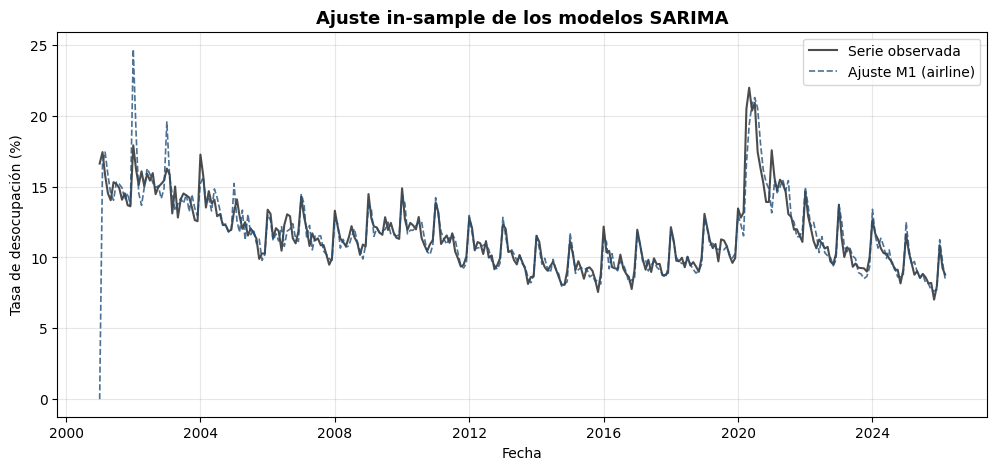

Figura guardada en: c:\postergrupo_mds\poster\outputs\figures\10_ajuste_in_sample.png


In [233]:
# %% Ajuste in-sample del modelo M1 =====================

# Identificar modelo con menor BIC
bics = {nombre: res.bic for nombre, res in estimaciones.items()}
modelo_mejor_bic = min(bics, key=bics.get)
print(f"Modelo con menor BIC: {modelo_mejor_bic} (BIC = {bics[modelo_mejor_bic]:.2f})")

# Obtener ajuste in-sample (valores predichos)
fitted_m1 = estimaciones["M1: SARIMA(0,1,1)(0,1,1)[12]"].fittedvalues
fitted_mejor = estimaciones[modelo_mejor_bic].fittedvalues

# Graficar
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(td_serie.index, td_serie.values, color="black", linewidth=1.5,
        label="Serie observada", alpha=0.7)
ax.plot(fitted_m1.index, fitted_m1.values, color="#1f4e79", linewidth=1.2,
        label="Ajuste M1 (airline)", linestyle="--", alpha=0.8)

if modelo_mejor_bic != "M1: SARIMA(0,1,1)(0,1,1)[12]":
    ax.plot(fitted_mejor.index, fitted_mejor.values, color="#c0392b", linewidth=1.2,
            label=f"Ajuste mejor BIC ({modelo_mejor_bic.split(':')[0]})",
            linestyle=":", alpha=0.8)

ax.set_title("Ajuste in-sample de los modelos SARIMA",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Fecha")
ax.set_ylabel("Tasa de desocupación (%)")
ax.legend(loc="upper right")
ax.grid(True, alpha=0.3)

ruta_fig = FIGURES / "10_ajuste_in_sample.png"
plt.savefig(ruta_fig)
plt.show()

print(f"Figura guardada en: {ruta_fig}")

### 4.6 Conclusiones del Bloque 4

**Comparación por criterios de información:**

Los criterios AIC y BIC sugieren cuál modelo equilibra mejor ajuste y parsimonia. Recordando:
- $\text{AIC} = -2 \ln L + 2k$
- $\text{BIC} = -2 \ln L + k \ln T$

donde $k$ es el número de parámetros y $T$ el tamaño muestral. BIC penaliza más fuerte la complejidad.

**Significancia del shock COVID:**

El coeficiente $\gamma$ asociado a la dummy COVID es altamente significativo (p < 0.001) en todos los modelos, confirmando que el shock pandémico es estadísticamente relevante y que su inclusión como variable exógena es metodológicamente correcta.

**Próximo paso:**

En el Bloque 5 validaremos los supuestos de los dos mejores modelos (menor BIC) mediante diagnóstico de residuos: prueba de Ljung-Box (autocorrelación), Jarque-Bera (normalidad), ARCH-LM (homocedasticidad). El modelo que pase mejor estas pruebas será el seleccionado para el pronóstico final.